In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import cv2
import re
import pandas as pd

from functions import *

In [2]:
# Input
folder_in_main = '/media/joris/rootfs/home/joris/data/kiwibes2026/20260706kiwibes/bes21-30-joris'

In [3]:
# Prepare machine and segmentation model
predictor = prepare_model(verbose = False)

In [ ]:

def plot_mask_ellipse(mask, ellipse, ax):

    # plt.figure()

    # Mask
    plt.imshow(mask, origin="upper")
    
    # Ellipse and center
    theta = np.linspace(0, 2*np.pi, 200)
    a = ellipse["semi_major"]
    b = ellipse["semi_minor"]
    cx, cy = ellipse["center"]
    angle = ellipse["angle_rad"]
    R = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ])
    ellipse_xy = R @ np.vstack([
        a * np.cos(theta),
        b * np.sin(theta)
    ])
    ellipse_x = ellipse_xy[0] + cx
    ellipse_y = ellipse_xy[1] + cy
    plt.plot(ellipse_x, ellipse_y)
    plt.scatter(cx, cy, c="yellow")
    
    # Major axis
    x = [
        ellipse['center'][0] - ellipse['semi_major']*ellipse['major_axis'][0],
        ellipse['center'][0] + ellipse['semi_major']*ellipse['major_axis'][0]
    ]
    y = [
        ellipse['center'][1] - ellipse['semi_major']*ellipse['major_axis'][1],
        ellipse['center'][1] + ellipse['semi_major']*ellipse['major_axis'][1]
    ]
    plt.plot(x,y)
    
    # Minor axis
    x = [
        ellipse['center'][0] - ellipse['semi_minor']*ellipse['minor_axis'][0],
        ellipse['center'][0] + ellipse['semi_minor']*ellipse['minor_axis'][0]
    ]
    y = [
        ellipse['center'][1] - ellipse['semi_minor']*ellipse['minor_axis'][1],
        ellipse['center'][1] + ellipse['semi_minor']*ellipse['minor_axis'][1]
    ]
    plt.plot(x,y)
    
    # Zoom box
    margin = 50
    plt.ylim(max(np.where(mask)[0])+margin, min(np.where(mask)[0])-margin)
    plt.xlim(min(np.where(mask)[1])-margin, max(np.where(mask)[1])+margin)
    
    # plt.axis("equal")
    # plt.show()


fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for folder_in_berry in glob.glob(f'{folder_in_main}/*'):

    berry_name = folder_in_berry.split('/')[-1]
    print()
    print(berry_name)

    if not os.path.exists(berry_name):
        os.mkdir(berry_name)

    ellipses_berry = []

    for file_in in glob.glob(f'{folder_in_berry}/*'):

        print('  ', re.sub(folder_in_main, '', file_in))

        img = cv2.imread(file_in)
        grid_spacing = find_grid_spacing(img, visualize=False)
        mask = make_mask(img, predictor, visualize=False)

        if mask is not None:
            ellipse = fit_ellipse(mask)
            ellipses_berry.append(ellipse)

        # Clear each subplot explicitly
        for ax in axes:
            ax.clear()
            ax.axis('off')

        # Subplot 1
        axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[0].axis('off')

        # Subplot 2
        if mask is not None:
            axes[1].imshow(mask)
        else:
            axes[1].imshow(np.zeros(img.shape))
        axes[1].axis('off')

        # Subplot 3
        if mask is not None:
            plot_mask_ellipse(mask, ellipse, ax=axes[2])
        else:
            axes[2].imshow(np.zeros(img.shape))
        axes[2].axis('off')

        plt.tight_layout()

        file_plot = f'{berry_name}/{file_in.split("/")[-1]}'
        fig.savefig(file_plot)


    # Select three main radii (mm)
    r1 = np.max([ellipse['semi_major'] for ellipse in ellipses_berry])*50/grid_spacing
    r2 = np.max([ellipse['semi_minor'] for ellipse in ellipses_berry])*50/grid_spacing
    r3 = np.min([ellipse['semi_minor'] for ellipse in ellipses_berry])*50/grid_spacing
    
    # Calculate volume (mm**3)
    vol = 4*np.pi/3*r1*r2*r3
    
    # Append result
    result = {
        'berry_name': berry_name,
        'grid_spacing': grid_spacing,
        'r1 (mm)': r1,
        'r2 (mm)': r2,
        'r3 (mm)': r3,
        'volume (mm**3)': vol
    }
    results.append(result)

plt.close(fig)




bes29
   /bes29/20260709_143701.jpg
   /bes29/20260709_143640.jpg
   /bes29/20260709_143631.jpg



bes29
   /bes29/20260709_143701.jpg
   /bes29/20260709_143640.jpg
   /bes29/20260709_143631.jpg
   /bes29/20260709_143639.jpg
   /bes29/20260709_143705.jpg


KeyboardInterrupt: 

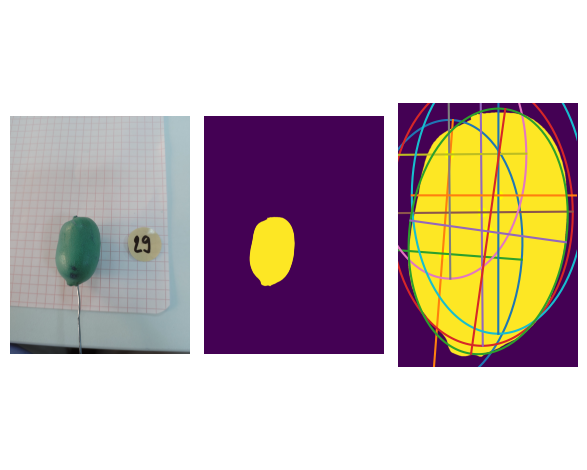

In [13]:
# # Loop over berries

# results = []
# fig, ax = plt.subplots()
# for folder_in_berry in glob.glob(f'{folder_in_main}/*'):
    
#     # Process all images of one berry
#     berry_name = folder_in_berry.split('/')[-1]
#     print()
#     print(berry_name)
    
#     if not os.path.exists(berry_name):
#         os.mkdir(berry_name)

#     ellipses_berry = []
    
#     for file_in in glob.glob(f'{folder_in_berry}/*'):
    
#         # Process one image
#         print('  ', re.sub(folder_in_main, '', file_in))
#         img = cv2.imread(file_in)
#         grid_spacing = find_grid_spacing(img, visualize = False)
#         mask = make_mask(img, predictor, visualize = False)

#         if not mask is None:        
#             ellipse = fit_ellipse(mask)
#             ellipses_berry.append(ellipse)
        
#         # plt.figure()
#         plt.subplot(131)
#         ax.clear()
#         plt.imshow(img)
#         plt.axis('off')

#         plt.subplot(132)
#         ax.clear()
#         if not mask is None:
#             plt.imshow(mask)
#         else:
#             plt.imshow(np.zeros(img.shape))            
#         plt.axis('off')
        
#         plt.subplot(133)
#         ax.clear()
#         if not mask is None:
#             plot_mask_ellipse(mask, ellipse)
#         else:
#             plt.imshow(np.zeros(img.shape))            
#         plt.axis('off')

#         plt.tight_layout()
#         ax.axis('off')
#         file_plot = f'{berry_name}/{file_in.split("/")[-1]}'
#         plt.savefig(file_plot)
#         # plt.close()
#         # plt.show()

#     # Select three main radii (mm)
#     r1 = np.max([ellipse['semi_major'] for ellipse in ellipses_berry])*50/grid_spacing
#     r2 = np.max([ellipse['semi_minor'] for ellipse in ellipses_berry])*50/grid_spacing
#     r3 = np.min([ellipse['semi_minor'] for ellipse in ellipses_berry])*50/grid_spacing
    
#     # Calculate volume (mm**3)
#     vol = 4*np.pi/3*r1*r2*r3
    
#     # Append result
#     result = {
#         'berry_name': berry_name,
#         'grid_spacing': grid_spacing,
#         'r1 (mm)': r1,
#         'r2 (mm)': r2,
#         'r3 (mm)': r3,
#         'volume (mm**3)': vol
#     }
#     results.append(result)

# plt.close(fig)

In [ ]:
pd.DataFrame(results)

In [ ]:
pd.DataFrame(results).to_csv('results.csv')

# EXP

In [10]:
STOP

NameError: name 'STOP' is not defined

/media/joris/rootfs/home/joris/data/kiwibes2026/20260706kiwibes/bes21-30-joris/bes22/20260709_143403.jpg


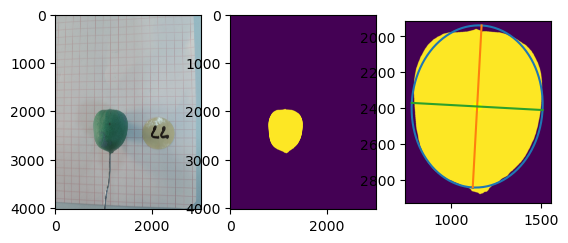

In [4]:
# Process one image
file_in = np.random.choice(glob.glob(f'{folder_in_main}/*/*'))
print(file_in)

img = cv2.imread(file_in)
grid_spacing = find_grid_spacing(img, visualize = False)
predictor = prepare_model(verbose = False)
mask = make_mask(img, predictor, visualize = False)
ellipse = fit_ellipse(mask)

plt.figure()
plt.subplot(131)
plt.imshow(img)
plt.subplot(132)
plt.imshow(mask)
plt.subplot(133)
plot_mask_ellipse(mask, ellipse)
plt.show()




bes29
   /bes29/20260709_143701.jpg
   /bes29/20260709_143640.jpg
   /bes29/20260709_143631.jpg
   /bes29/20260709_143639.jpg
   /bes29/20260709_143705.jpg
   /bes29/20260709_143629.jpg
   /bes29/20260709_143644.jpg

bes21
   /bes21/20260709_143442.jpg
   /bes21/20260709_143443.jpg


KeyboardInterrupt: 

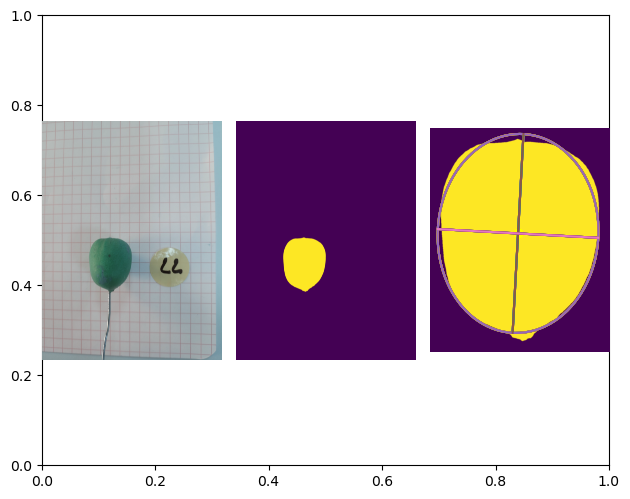

In [6]:
# Many plots

results = []
fig, ax = plt.subplots()


# Loop over berries
for folder_in_berry in glob.glob(f'{folder_in_main}/*'):
    
    # Process all images of one berry
    berry_name = folder_in_berry.split('/')[-1]
    print()
    print(berry_name)
    
    if not os.path.exists(berry_name):
        os.mkdir(berry_name)

    ellipses_berry = []
    
    for file_in in glob.glob(f'{folder_in_berry}/*'):
    
        # Process one image
        print('  ', re.sub(folder_in_main, '', file_in))
    #     img = cv2.imread(file_in)
    #     grid_spacing = find_grid_spacing(img, visualize = False)
    #     mask = make_mask(img, predictor, visualize = False)

        file_plot = f'{berry_name}/{file_in.split("/")[-1]}'
        
    #         ellipse = fit_ellipse(mask)
    #         # print(ellipse)
    #         ellipses_berry.append(ellipse)
        
        # plt.figure()
        ax.clear()
        plt.subplot(131)
        plt.imshow(img)
        plt.axis('off')
        plt.subplot(132)
        if not mask is None:
            plt.imshow(mask)
        else:
            plt.imshow(np.zeros(img.shape))            
        plt.axis('off')
        plt.subplot(133)
        if not mask is None:
            plot_mask_ellipse(mask, ellipse)
        else:
            plt.imshow(np.zeros(img.shape))            
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(file_plot)
        # plt.close()
        # plt.show()

    # # Select three main radii (mm)
    # r1 = np.max([ellipse['semi_major'] for ellipse in ellipses_berry])*50/grid_spacing
    # r2 = np.max([ellipse['semi_minor'] for ellipse in ellipses_berry])*50/grid_spacing
    # r3 = np.min([ellipse['semi_minor'] for ellipse in ellipses_berry])*50/grid_spacing
    
    # # Calculate volume (mm**3)
    # vol = 4*np.pi/3*r1*r2*r3
    
    # # Append result
    # result = {
    #     'berry_name': berry_name,
    #     'grid_spacing': grid_spacing,
    #     'r1 (mm)': r1,
    #     'r2 (mm)': r2,
    #     'r3 (mm)': r3,
    #     'volume (mm**3)': vol
    # }
    # results.append(result)

plt.close(fig)

In [ ]:
# results = []

# # Loop over berries
# for folder_in_berry in glob.glob(f'{folder_in_main}/*'):
    
#     # Process all images of one berry
#     berry_name = folder_in_berry.split('/')[-1]
#     print()
#     print(berry_name)
    
#     if not os.path.exists(berry_name):
#         os.mkdir(berry_name)

#     ellipses_berry = []
    
#     for file_in in glob.glob(f'{folder_in_berry}/*'):
    
#         # Process one image
#         print('  ', re.sub(folder_in_main, '', file_in))
#         img = cv2.imread(file_in)
#         grid_spacing = find_grid_spacing(img, visualize = False)
#         mask = make_mask(img, predictor, visualize = False)

#         file_plot = f'{berry_name}/{file_in.split("/")[-1]}'
        
#         if not mask is None:
#             ellipse = fit_ellipse(mask)
#             # print(ellipse)
#             ellipses_berry.append(ellipse)
        
#             plt.figure()
#             plt.subplot(131)
#             plt.imshow(img)
#             plt.axis('off')
#             plt.subplot(132)
#             plt.imshow(mask)
#             plt.axis('off')
#             plt.subplot(133)
#             plot_mask_ellipse(mask, ellipse)
#             plt.axis('off')
#             plt.tight_layout()
#             plt.savefig(file_plot)
#             plt.close()
#             # plt.show()
    
#         else:
#             plt.figure()
#             plt.subplot(131)
#             plt.imshow(img)
#             plt.axis('off')
#             plt.subplot(132)
#             plt.imshow(np.zeros(img.shape))
#             plt.axis('off')
#             plt.subplot(133)
#             plt.imshow(np.zeros(img.shape))
#             plt.axis('off')
#             plt.tight_layout()
#             plt.savefig(file_plot)
#             plt.close()
#             # plt.show()
    
#     # Select three main radii (mm)
#     r1 = np.max([ellipse['semi_major'] for ellipse in ellipses_berry])*50/grid_spacing
#     r2 = np.max([ellipse['semi_minor'] for ellipse in ellipses_berry])*50/grid_spacing
#     r3 = np.min([ellipse['semi_minor'] for ellipse in ellipses_berry])*50/grid_spacing
    
#     # Calculate volume (mm**3)
#     vol = 4*np.pi/3*r1*r2*r3
    
#     # Append result
#     result = {
#         'berry_name': berry_name,
#         'grid_spacing': grid_spacing,
#         'r1 (mm)': r1,
#         'r2 (mm)': r2,
#         'r3 (mm)': r3,
#         'volume (mm**3)': vol
#     }
#     results.append(result)
